In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import zipfile
import os

project_path = '/content/drive/MyDrive/Colab Notebooks/CS-163'

# 1. Load Demographics Data
coc_path = os.path.join(project_path, 'communities_of_concern_2020_acs2018_-1910075097215603691.csv')
df_demographics = pd.read_csv(coc_path)

# 2. Load Ridership Data (Using October 2024 as an example, adjust if you prefer 2025)
ridership_path = os.path.join(project_path, 'OCT_2024_RBS_FULL_DATA_SET_BY_STOP_FINAL.xlsx')
df_ridership = pd.read_excel(ridership_path)

# 3. Load GTFS Stops (for Spatial Join coordinates)
gtfs_zip_path = os.path.join(project_path, 'gtfs_vta.zip')
with zipfile.ZipFile(gtfs_zip_path, 'r') as z:
    with z.open('stops.txt') as f:
        df_stops = pd.read_csv(f)

print("Demographics Columns:", df_demographics.columns.tolist()[:10])
print("\nRidership Columns:", df_ridership.columns.tolist()[:10])
print("\nGTFS Stops Columns:", df_stops.columns.tolist()[:10])

display(df_stops.head(3))

Demographics Columns: ['objectid', 'Geographic ID', 'State FIPS', 'County FIPS', 'Census Tract', 'Total Population', 'Total Population for Income', 'Total Civilian Population', 'Total Households', 'Total Families']

Ridership Columns: ['Stop_ID_Num', 'SERVICE_PERIOD', 'MAIN_CROSS_STREET', 'ROUTES_SERVED', 'AVG_BOARDINGS', 'AVG_ALIGHTINGS', 'AVG_ACTIVITY']

GTFS Stops Columns: ['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'zone_id', 'stop_url', 'location_type', 'parent_station']


,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,wheelchair_boarding,platform_code,sign_dest
0,EL_VIR,NaN,Virginia Station Elevator,NaN,37.32000,-121.89019,NaN,NaN,2,PS_VIRG,1,NaN,NaN
1,EL_TMN,NaN,Tamien Station Elevator,NaN,37.31105,-121.88414,NaN,NaN,2,PS_TAMN,1,NaN,NaN
2,EL_CUR,NaN,Curtner Station Elevator,NaN,37.29267,-121.87220,NaN,NaN,2,PS_CULR,1,NaN,NaN


In [ ]:
# Prepare for Ridership + GTFS Merge
df_ridership['Stop_ID_clean'] = df_ridership['Stop_ID_Num'].astype(str).str.replace('.0', '', regex=False)
df_stops['stop_id_clean'] = df_stops['stop_id'].astype(str)
df_stops['stop_code_clean'] = df_stops['stop_code'].astype(str).str.replace('.0', '', regex=False)

In [ ]:
# Prepare for Ridership + GTFS Merge
df_ridership['Stop_ID_clean'] = df_ridership['Stop_ID_Num'].astype(str).str.replace('.0', '', regex=False)
df_stops['stop_id_clean'] = df_stops['stop_id'].astype(str)
df_stops['stop_code_clean'] = df_stops['stop_code'].astype(str).str.replace('.0', '', regex=False)

#\Check if Ridership IDs exist in GTFS stop_id or GTFS stop_code
matches_in_stop_id = df_ridership['Stop_ID_clean'].isin(df_stops['stop_id_clean']).sum()
print(f"Ridership Stop IDs found in GTFS 'stop_id': {matches_in_stop_id} out of {len(df_ridership)}")

matches_in_stop_code = df_ridership['Stop_ID_clean'].isin(df_stops['stop_code_clean']).sum()
print(f"Ridership Stop IDs found in GTFS 'stop_code': {matches_in_stop_code} out of {len(df_ridership)}")

Ridership Stop IDs found in GTFS 'stop_id': 0 out of 3202
Ridership Stop IDs found in GTFS 'stop_code': 3133 out of 3202


In [ ]:
# Merge coordinates to ridership data
df_merged = pd.merge(
    df_ridership,
    df_stops[['stop_code_clean', 'stop_name', 'stop_lat', 'stop_lon']],
    left_on='Stop_ID_clean',
    right_on='stop_code_clean',
    how='inner'
)

display(df_merged.head())

,Stop_ID_Num,SERVICE_PERIOD,MAIN_CROSS_STREET,ROUTES_SERVED,AVG_BOARDINGS,AVG_ALIGHTINGS,AVG_ACTIVITY,Stop_ID_clean,stop_code_clean,stop_name,stop_lat,stop_lon
0,60001.0,Weekday,SANTA CLARA TRANSIT CENTER,22,153.472166,107.944787,261.416953,60001,60001,Santa Clara Transit Center (Bay 4),37.353055,-121.936671
1,60008.0,Weekday,SAN JOSE AIRPORT - TERMINAL A,60,195.758700,146.315555,342.074256,60008,60008,SJC Airport Terminal A,37.370456,-121.930182
2,60011.0,Weekday,SAN JOSE AIRPORT - TERMINAL B,60,97.672356,73.809464,171.481819,60011,60011,SJC Airport Terminal B,37.364453,-121.923073
3,60014.0,Weekday,1ST + METRO,60,116.676604,59.498322,176.174925,60014,60014,Metro Station,37.369770,-121.915884
4,60020.0,Weekday,EL CAMINO + LAFAYETTE,"22, 59, 60",57.256527,58.961911,116.218439,60020,60020,El Camino & Lafayette,37.355057,-121.945135


In [ ]:
import geopandas as gpd

# Convert merged ridership data into a GeoDataFrame
gdf_stops = gpd.GeoDataFrame(
    df_merged,
    geometry=gpd.points_from_xy(df_merged.stop_lon, df_merged.stop_lat),
    crs="EPSG:4326" # Standard WGS84 latitude/longitude
)

print(f"Created GeoDataFrame with {len(gdf_stops)} stops. Ready for spatial join!")
display(gdf_stops[['Stop_ID_clean', 'stop_name', 'geometry']].head())

Created GeoDataFrame with 3648 stops. Ready for spatial join!


,Stop_ID_clean,stop_name,geometry
0,60001,Santa Clara Transit Center (Bay 4),POINT (-121.93667 37.35306)
1,60008,SJC Airport Terminal A,POINT (-121.93018 37.37046)
2,60011,SJC Airport Terminal B,POINT (-121.92307 37.36445)
3,60014,Metro Station,POINT (-121.91588 37.36977)
4,60020,El Camino & Lafayette,POINT (-121.94514 37.35506)


In [ ]:
import urllib.request

# URL for 2018 California Census Tracts
tract_zip_url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_06_tract_500k.zip"
tract_zip_path = os.path.join(project_path, "cb_2018_06_tract_500k.zip")
extract_dir = os.path.join(project_path, "ca_tracts_2018")

# Download if it doesn't exist
if not os.path.exists(tract_zip_path):
    print("Downloading CA Tract shapefile from US Census Bureau...")
    urllib.request.urlretrieve(tract_zip_url, tract_zip_path)
    print("Download complete.")

# Extract if not already extracted
if not os.path.exists(extract_dir):
    print("Extracting shapefile...")
    with zipfile.ZipFile(tract_zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")

# Load the tract shapefile
shp_path = os.path.join(extract_dir, "cb_2018_06_tract_500k.shp")
gdf_tracts = gpd.read_file(shp_path)

print(f"Loaded {len(gdf_tracts)} California census tracts!")
display(gdf_tracts[['GEOID', 'TRACTCE', 'geometry']].head(3))


Loaded 8041 California census tracts!


,GEOID,TRACTCE,geometry
0,06009000300,000300,"POLYGON ((-120.76399 38.21389, -120.76197 38.2..."
1,06011000300,000300,"POLYGON ((-122.50006 39.12232, -122.50022 39.1..."
2,06013303102,303102,"POLYGON ((-121.72937 37.96884, -121.71409 37.9..."


In [ ]:
# Construct the standard 11-digit GEOID in the demographics dataset to match the shapefile
# State (2 chars) + County (3 chars) + Tract (6 chars)
df_demographics['GEOID'] = (
    df_demographics['State FIPS'].astype(str).str.zfill(2) +
    df_demographics['County FIPS'].astype(str).str.zfill(3) +
    df_demographics['Census Tract'].astype(str).str.zfill(6)
)

# Merge Demographics Data with the Tract Geometries
gdf_demographics = gdf_tracts.merge(
    df_demographics,
    on='GEOID',
    how='inner'
)
print(f"Matched {len(gdf_demographics)} demographic records to tract boundaries.")

# Perform the Spatial Join
# Ensure coordinate reference systems (CRS) match
gdf_stops = gdf_stops.to_crs(gdf_demographics.crs)

# Join bus stops (points) to demographic tracts (polygons)
final_joined_gdf = gpd.sjoin(
    gdf_stops,
    gdf_demographics,
    how="inner",
    predicate="within"
)

print(f"\nSuccess! Spatial Join complete. Final dataset has {len(final_joined_gdf)} bus stops with attached demographics.")
display(final_joined_gdf[['Stop_ID_clean', 'stop_name', 'Total Population', 'Percent Low-Income']].head())


Matched 339 demographic records to tract boundaries.

Success! Spatial Join complete. Final dataset has 556 bus stops with attached demographics.


,Stop_ID_clean,stop_name,Total Population,Percent Low-Income
1,60008,SJC Airport Terminal A,3985,0.303639
2,60011,SJC Airport Terminal B,3985,0.303639
3,60014,Metro Station,3985,0.303639
7,60032,King & Mabury,3148,0.470930
8,60033,King & Las Plumas,3148,0.470930


## Build Route-Level Metrics
### Demand and Need Metrics

In [ ]:
# Split ROUTES_SERVED into individual routes
df_route_stops = final_joined_gdf.copy()
df_route_stops['Route'] = df_route_stops['ROUTES_SERVED'].astype(str).str.split(',')
df_route_stops = df_route_stops.explode('Route')
df_route_stops['Route'] = df_route_stops['Route'].str.strip()

# Aggregate metrics by Route
route_metrics = df_route_stops.groupby('Route').agg(
    Avg_Boardings=('AVG_BOARDINGS', 'sum'),

    # Need Metrics (from the coc_data)
    Avg_Percent_Low_Income=('Percent Low-Income', 'mean'),
    Avg_Percent_Zero_Vehicle=('Percent Zero-Vehicle Household', 'mean'),
    Total_Population_Served=('Total Population', 'sum'),

    # General info (only the stops within coc tracts are left in data)
    Stops_In_Disadvantaged_Tracts=('Stop_ID_clean', 'count')
).reset_index()

# Clean up any empty/nan routes
route_metrics = route_metrics[(route_metrics['Route'] != 'nan') & (route_metrics['Route'] != '')]

display(route_metrics.sort_values('Avg_Boardings', ascending=False).head())

,Route,Avg_Boardings,Avg_Percent_Low_Income,Avg_Percent_Zero_Vehicle,Total_Population_Served,Stops_In_Disadvantaged_Tracts
31,66,9097.046387,0.419740,0.119120,303671,57
8,22,7350.921272,0.403029,0.096872,184260,41
9,23,7064.548989,0.410345,0.155068,164666,38
36,73,5820.735058,0.463770,0.145720,226406,46
35,72,5524.821834,0.455350,0.107288,186736,41


### Supply Metrics (GTFS)

In [ ]:
# Extract trips and routes from the GTFS zip
with zipfile.ZipFile(gtfs_zip_path, 'r') as z:
    with z.open('trips.txt') as f:
        df_trips = pd.read_csv(f)
    with z.open('routes.txt') as f:
        df_routes = pd.read_csv(f)

# Calculate Supply (Trips per route)
trips_per_route = df_trips.groupby('route_id').size().reset_index(name='Total_Scheduled_Trips')

# Merge with routes to get route name (route_short_name)
df_supply = pd.merge(trips_per_route, df_routes[['route_id', 'route_short_name']], on='route_id')
df_supply['Route'] = df_supply['route_short_name'].astype(str).str.strip()

# Merge Supply back into our main route_metrics dataframe
route_metrics_final = pd.merge(route_metrics, df_supply[['Route', 'Total_Scheduled_Trips']], on='Route', how='inner')

display(route_metrics_final.sort_values('Total_Scheduled_Trips', ascending=False).head())

,Route,Avg_Boardings,Avg_Percent_Low_Income,Avg_Percent_Zero_Vehicle,Total_Population_Served,Stops_In_Disadvantaged_Tracts,Total_Scheduled_Trips
5,22,7350.921272,0.403029,0.096872,184260,41,424
7,25,3783.510888,0.390169,0.078517,259622,48,401
6,23,7064.548989,0.410345,0.155068,164666,38,397
17,60,831.621508,0.319560,0.122220,79871,17,335
21,66,9097.046387,0.419740,0.119120,303671,57,325


## Calculate Underserved Score
From our coc data, we normalized values to calulate an 'underserved' score of need * service level / supply (trips per route)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df_metrics = route_metrics_final.copy()

# Normalize features between 0 and 1 so they carry equal weight
scaler = MinMaxScaler()

df_metrics['Demand_Score'] = scaler.fit_transform(df_metrics[['Avg_Boardings']])

# For Need, we combine Low Income and Zero Vehicle Household percentages
need_interaction = df_metrics['Avg_Percent_Low_Income'] * df_metrics['Avg_Percent_Zero_Vehicle']
df_metrics['Need_Score'] = scaler.fit_transform(need_interaction.values.reshape(-1, 1))

df_metrics['Service_Score'] = scaler.fit_transform(df_metrics[['Total_Scheduled_Trips']])
# Add a small constant to avoid division by zero
df_metrics['Service_Score'] = df_metrics['Service_Score'] + 0.05

# Calculate Underserved Score: (Demand * Need) / Service
df_metrics['Underserved_Score'] = (df_metrics['Demand_Score'] * df_metrics['Need_Score']) / df_metrics['Service_Score']

print("Top 10 Most Underserved Routes:")
display(df_metrics[['Route', 'Avg_Boardings', 'Total_Scheduled_Trips', 'Underserved_Score']].sort_values('Underserved_Score', ascending=False).head(10))

Top 10 Most Underserved Routes:


,Route,Avg_Boardings,Total_Scheduled_Trips,Underserved_Score
20,64B,3341.358770,100,0.665995
26,73,5820.735058,267,0.606052
21,66,9097.046387,325,0.572298
1,201,256.662621,3,0.533513
6,23,7064.548989,397,0.474341
25,72,5524.821834,268,0.406184
2,202,256.662621,3,0.353279
19,64A,3273.563648,198,0.352949
22,68,4949.741600,325,0.286065
5,22,7350.921272,424,0.274578


## Clustering


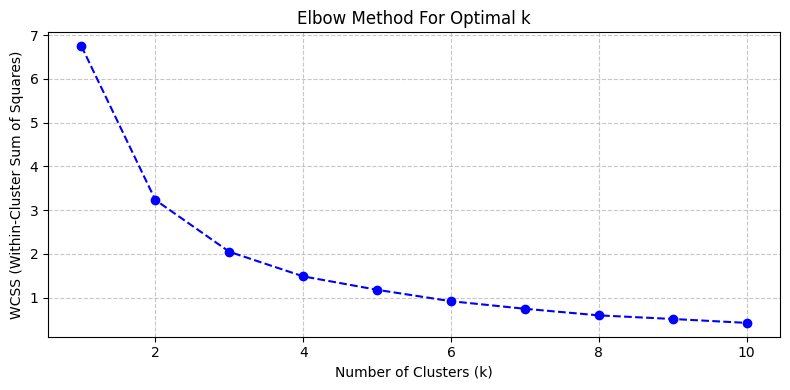

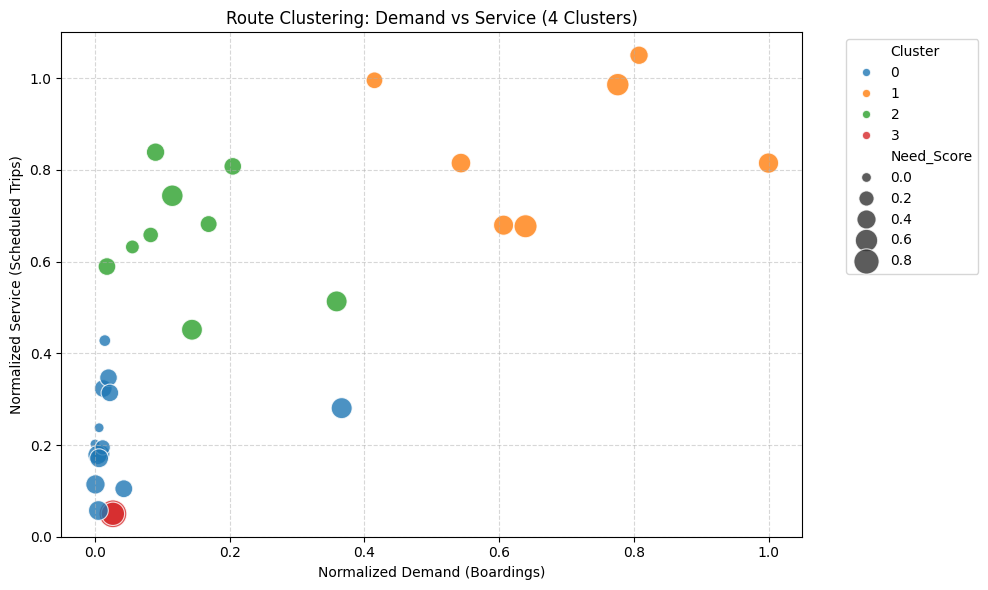


Cluster Profiles (Average Scores):


,Demand_Score,Need_Score,Service_Score,Underserved_Score
Cluster,,,,
3,0.026676,0.831088,0.050000,0.443396
1,0.684045,0.460635,0.859637,0.390475
2,0.137470,0.353680,0.657284,0.092703
0,0.037210,0.286794,0.223736,0.067738


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Features for clustering
X = df_metrics[['Demand_Score', 'Need_Score', 'Service_Score']]

wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X)
    wcss.append(kmeans_temp.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Fit K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_metrics['Cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_metrics,
    x='Demand_Score',
    y='Service_Score',
    hue='Cluster',
    size='Need_Score',
    sizes=(50, 400),
    palette='tab10',
    alpha=0.8
)
plt.title('Route Clustering: Demand vs Service (4 Clusters)')
plt.xlabel('Normalized Demand (Boardings)')
plt.ylabel('Normalized Service (Scheduled Trips)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Show average scores per cluster
cluster_profile = df_metrics.groupby('Cluster')[['Demand_Score', 'Need_Score', 'Service_Score', 'Underserved_Score']].mean()
display(cluster_profile.sort_values('Underserved_Score', ascending=False))

### Interactive Geospatial Map


In [ ]:
import plotly.express as px

# 1. Merge the calculated route metrics (Clusters, Underserved Score) back to the spatial stop data
# We use df_route_stops because it contains 'Route', 'stop_lat', 'stop_lon', 'stop_name', and demographics
map_data = pd.merge(
    df_route_stops,
    df_metrics[['Route', 'Cluster', 'Underserved_Score']],
    on='Route',
    how='inner'
)

# Convert Cluster to a string so Plotly treats it as a distinct category rather than a continuous number
map_data['Cluster_Label'] = 'Cluster ' + map_data['Cluster'].astype(str)

# Fill any missing values in the score so sizes don't break
map_data['Underserved_Score'] = map_data['Underserved_Score'].fillna(0) + 0.01 # Add small buffer for size=0

# 2. Create the interactive map using Plotly Express
fig = px.scatter_mapbox(
    map_data,
    lat="stop_lat",
    lon="stop_lon",
    color="Cluster_Label",          # Color stops by their Route's Cluster
    size="Underserved_Score",       # Size of the bubble based on the Underserved Score
    hover_name="stop_name",         # Tooltip title
    hover_data={                    # Extra data in the tooltip
        "Route": True,
        "Underserved_Score": ':.3f',
        "Percent Low-Income": ':.2%',
        "Total Population": True,
        "stop_lat": False,          # Hide raw lat/lon in tooltip
        "stop_lon": False,
        "Cluster_Label": False
    },
    color_discrete_sequence=px.colors.qualitative.G10,
    zoom=10,
    mapbox_style="carto-positron",  # Clean, light background map
    title="Interactive Route Metrics Map (Ready for Dash Integration)",
    height=600
)

# 3. Display the map in Colab
fig.show()

# Note for Dash:
# In your app.py, you would just do:
# app.layout = html.Div([ dcc.Graph(figure=fig) ])


In [ ]:
# Export the map data to a CSV file for use in the Dash app
csv_filename = 'route_metrics_map_data.csv'
csv_path = os.path.join(project_path, csv_filename)

map_data.to_csv(csv_path, index=False)
print(f"Successfully exported map data to: {csv_path}")

Successfully exported map data to: /content/drive/MyDrive/Colab Notebooks/CS-163/route_metrics_map_data.csv


## Prediction (Machine Learning)
Predicting if a route is flagged as "Underserved" using a Random Forest Classifier.

Total routes in dataset: 32
Class Balance:
Is_Underserved
0    24
1     8

--- Cross-Validated Model Evaluation ---
Overall Accuracy: 0.84

                     precision    recall  f1-score   support

Not Underserved (0)       0.88      0.92      0.90        24
    Underserved (1)       0.71      0.62      0.67         8

           accuracy                           0.84        32
          macro avg       0.80      0.77      0.78        32
       weighted avg       0.84      0.84      0.84        32



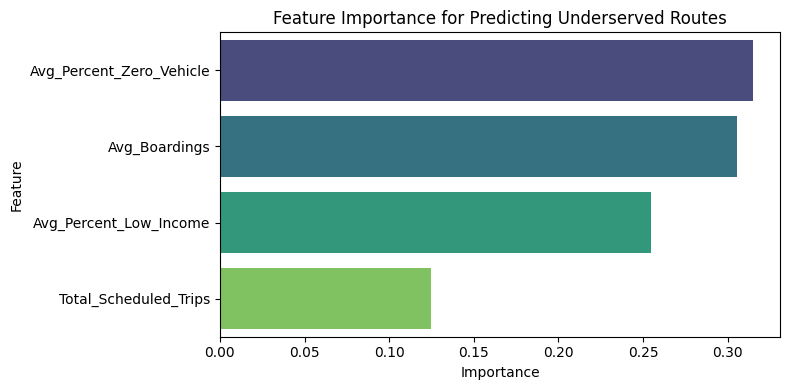

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the Target Variable
# 'Underserved' is defined as being in the top 25% of the Underserved_Score
threshold = df_metrics['Underserved_Score'].quantile(0.75)
df_metrics['Is_Underserved'] = (df_metrics['Underserved_Score'] >= threshold).astype(int)

# 2. Select Features for Prediction
features = ['Avg_Boardings', 'Total_Scheduled_Trips', 'Avg_Percent_Low_Income', 'Avg_Percent_Zero_Vehicle']
X_ml = df_metrics[features]
y_ml = df_metrics['Is_Underserved']

print(f"Total routes in dataset: {len(df_metrics)}")
print(f"Class Balance:\n{y_ml.value_counts().to_string()}\n")

# 3. Train a Random Forest Model with Balanced Class Weights
# 'balanced' forces the model to pay more attention to the minority "Underserved" class
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 4. Use Stratified Cross-Validation due to small dataset size
# This splits the 32 rows into 4 folds, ensuring each fold has the same ratio of underserved routes
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# cross_val_predict generates cross-validated estimates for each input data point
y_pred_cv = cross_val_predict(rf_model, X_ml, y_ml, cv=cv)

# 5. Evaluate the Model over the entire Cross-Validated dataset
print("--- Cross-Validated Model Evaluation ---")
print(f"Overall Accuracy: {accuracy_score(y_ml, y_pred_cv):.2f}\n")

target_names = ['Not Underserved (0)', 'Underserved (1)']
print(classification_report(y_ml, y_pred_cv, target_names=target_names))

# 6. Fit final model on all data to extract Feature Importances
rf_model.fit(X_ml, y_ml)

importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, palette='viridis', hue=importances.index, dodge=False)
plt.title('Feature Importance for Predicting Underserved Routes')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


<Figure size 800x600 with 0 Axes>

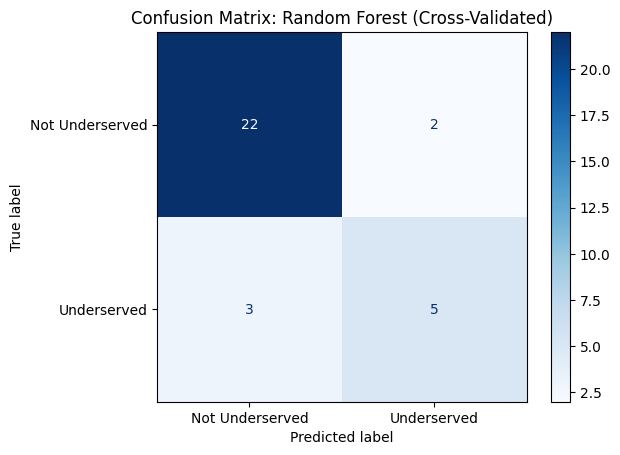

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_ml, y_pred_cv)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Underserved', 'Underserved'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Random Forest (Cross-Validated)')
plt.grid(False)
plt.show()

Time-Series Data Preparation

In [ ]:
df_long = pd.melt(
    df_2025_avg,
    id_vars=['Route'],
    var_name='Time_Period',
    value_name='Average_Ridership'
)

df_long_wk = df_long[df_long['Time_Period'].str.endswith('_WK')].copy()

# Extract Month and Year from 'Time_Period'
# 'F7_1_2005_WK' -> Month=7, Year=2005
df_long_wk['Month'] = df_long_wk['Time_Period'].apply(lambda x: x.split('_')[0].replace('F', ''))
df_long_wk['Year'] = df_long_wk['Time_Period'].apply(lambda x: x.split('_')[2])

df_long_wk['Date'] = pd.to_datetime(df_long_wk['Year'] + '-' + df_long_wk['Month'] + '-01')

df_ts = df_long_wk[['Route', 'Date', 'Average_Ridership']].copy()
df_ts['Average_Ridership'] = pd.to_numeric(df_ts['Average_Ridership'], errors='coerce').fillna(0)
df_ts = df_ts.sort_values(['Route', 'Date']).reset_index(drop=True)

print(f"Time-series dataset created with {len(df_ts)} records.")
print(f"Data ranges from {df_ts['Date'].min().date()} to {df_ts['Date'].max().date()}\n")
display(df_ts.head())

Time-series dataset created with 29436 records.
Data ranges from 2005-07-01 to 2025-08-01



,Route,Date,Average_Ridership
0,10.0,2005-07-01,1470.0
1,10.0,2005-08-01,1365.0
2,10.0,2005-09-01,1352.0
3,10.0,2005-10-01,1306.0
4,10.0,2005-11-01,1312.0


Time-Series Forecasting (Prophet)

Selected Route for Forecasting: 22.0


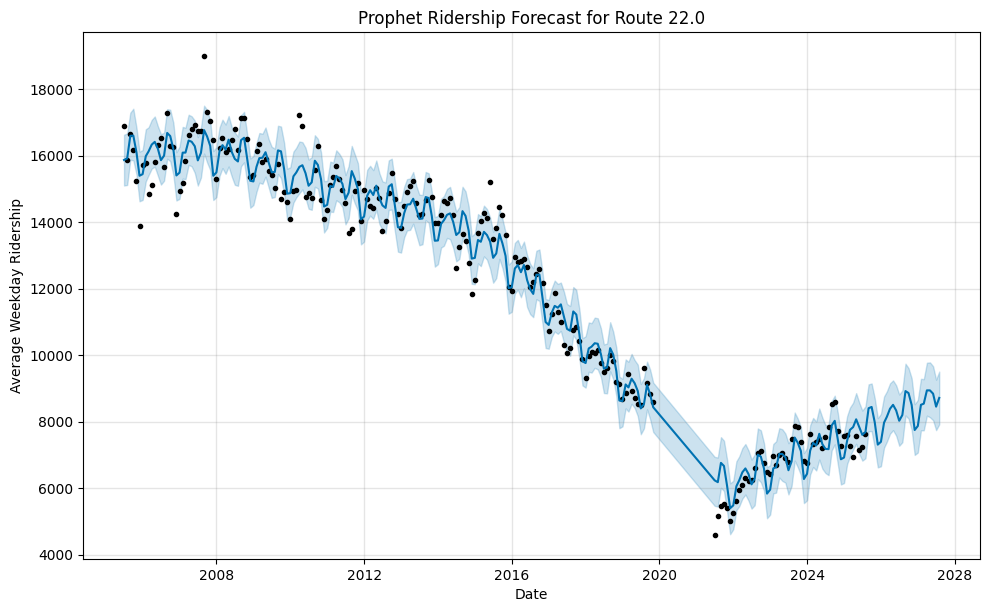

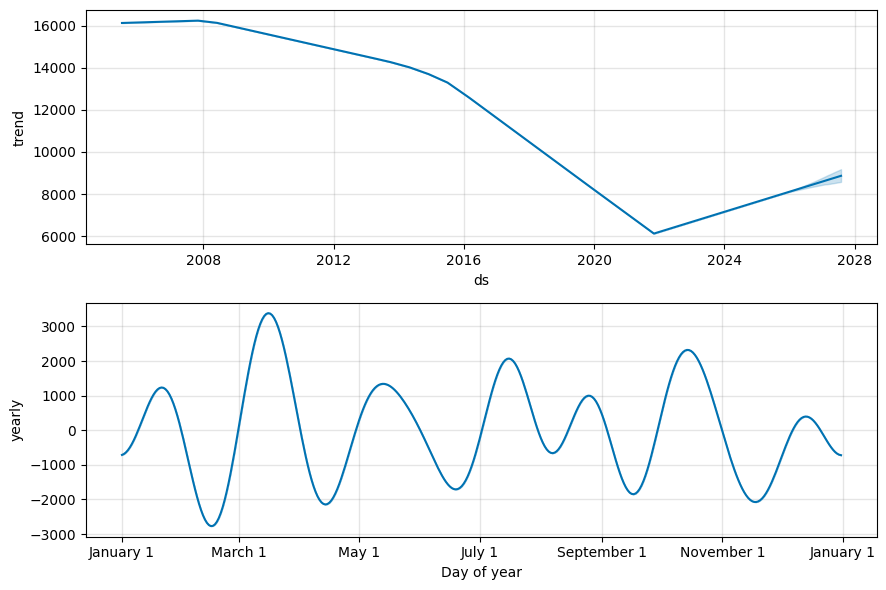

In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. Pick a route to forecast. Let's find the route with the highest recent ridership.
# We will filter out 'NaN' routes first.
valid_routes = df_ts.dropna(subset=['Route'])
top_route = valid_routes.groupby('Route')['Average_Ridership'].sum().idxmax()
print(f"Selected Route for Forecasting: {top_route}")

# 2. Prepare the data for Prophet
# Prophet requires columns to be named 'ds' (datestamp) and 'y' (numeric value)
df_prophet = valid_routes[valid_routes['Route'] == top_route][['Date', 'Average_Ridership']].copy()
df_prophet.rename(columns={'Date': 'ds', 'Average_Ridership': 'y'}, inplace=True)

# 3. Initialize and Fit the Model
# We enable yearly seasonality since transit ridership typically follows annual school/weather cycles
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df_prophet)

# 4. Create a future dataframe for 24 months into the future
future = model.make_future_dataframe(periods=24, freq='MS') # 'MS' = Month Start

# 5. Predict the future
forecast = model.predict(future)

# 6. Plot the results
fig = model.plot(forecast)
plt.title(f'Prophet Ridership Forecast for Route {top_route}')
plt.xlabel('Date')
plt.ylabel('Average Weekday Ridership')
plt.show()

# Plot the individual components (trend and seasonality)
fig_components = model.plot_components(forecast)
plt.show()

Training Route Specific Models

In [ ]:
import pandas as pd
from prophet import Prophet

# 1. Initialize list for results and a dictionary for the models
forecast_results = []
prophet_models_dict = {}

# 2. Get unique routes (excluding any NaN values)
unique_routes = df_ts['Route'].dropna().unique()

print(f"Starting forecasts for {len(unique_routes)} routes...")

# 3. Iterate through each route
for route in unique_routes:
    try:
        # Filter data for the specific route
        route_data = df_ts[df_ts['Route'] == route][['Date', 'Average_Ridership']].copy()

        # Prepare for Prophet
        route_data.rename(columns={'Date': 'ds', 'Average_Ridership': 'y'}, inplace=True)

        # 4. Initialize and fit model
        m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, interval_width=0.95)
        m.fit(route_data)

        # Store the model in the dictionary using the route as the key
        prophet_models_dict[str(route)] = m

        # 5. Create 12-month future dataframe
        future = m.make_future_dataframe(periods=12, freq='MS')
        forecast = m.predict(future)

        # 6. Extract the forecast for the horizon (the last row)
        last_forecast_row = forecast.iloc[-1]

        forecast_results.append({
            'Route': route,
            'Current_Average': route_data['y'].iloc[-1],
            'Forecasted_Boardings': last_forecast_row['yhat'],
            'Forecast_Date': last_forecast_row['ds']
        })
    except Exception as e:
        print(f"Skipping Route {route} due to error: {e}")

# 7. Consolidate into df_future_forecasts
df_future_forecasts = pd.DataFrame(forecast_results)

print("Consolidated 12-Month Forecasts and stored models for all routes.")
display(df_future_forecasts.head())
print(f"Total routes forecasted: {len(df_future_forecasts)}")

Starting forecasts for 118 routes...
Consolidated 12-Month Forecasts and stored models for all routes.


,Route,Current_Average,Forecasted_Boardings,Forecast_Date
0,10.0,0.0,-370.713470,2026-08-01
1,11.0,0.0,-29.144321,2026-08-01
2,12.0,0.0,0.000000,2026-08-01
3,13.0,0.0,-62.121610,2026-08-01
4,14.0,0.0,-43.888791,2026-08-01


Total routes forecasted: 118


In [ ]:
# Standardize 'Route' columns in both DataFrames
route_metrics_final['Route'] = route_metrics_final['Route'].astype(str).str.replace('.0', '', regex=False).str.strip()
df_future_forecasts['Route'] = df_future_forecasts['Route'].astype(str).str.replace('.0', '', regex=False).str.strip()

df_metrics_future = pd.merge(
    route_metrics_final,
    df_future_forecasts,
    on='Route',
    how='inner'
)

# Verify the merge
print(f"Merge successful. New DataFrame 'df_metrics_future' has {len(df_metrics_future)} routes.")
display(df_metrics_future.head())

Merge successful. New DataFrame 'df_metrics_future' has 30 routes.


,Route,Avg_Boardings,Avg_Percent_Low_Income,Avg_Percent_Zero_Vehicle,Total_Population_Served,Stops_In_Disadvantaged_Tracts,Total_Scheduled_Trips,Current_Average,Forecasted_Boardings,Forecast_Date
0,20,96.656606,0.291041,0.121480,45304,7,58,863.666700,1090.985448,2026-08-01
1,201,256.662621,0.408587,0.253176,8478,2,3,4.666667,-305.273141,2026-08-01
2,202,256.662621,0.376205,0.185038,16298,3,3,0.000000,12.811233,2026-08-01
3,203,60.902341,0.303639,0.154244,7970,2,6,0.000000,-11.834739,2026-08-01
4,21,125.597576,0.291041,0.121480,51776,8,118,1433.143000,1922.597032,2026-08-01


In [ ]:
import numpy as np

# 1. Update Avg_Boardings with Forecasted values (clipping negative values to 0)
df_metrics_future['Avg_Boardings'] = df_metrics_future['Forecasted_Boardings'].clip(lower=0)

# 2. Recalculate Normalized Scores for the Future Scenario
# Re-using the scaler logic from previous cells to maintain consistency
scaler_future = MinMaxScaler()

df_metrics_future['Demand_Score'] = scaler_future.fit_transform(df_metrics_future[['Avg_Boardings']])

# Need Score (Interaction of Income and Zero-Vehicle)
need_interaction_fut = df_metrics_future['Avg_Percent_Low_Income'] * df_metrics_future['Avg_Percent_Zero_Vehicle']
df_metrics_future['Need_Score'] = scaler_future.fit_transform(need_interaction_fut.values.reshape(-1, 1))

# Service Score
df_metrics_future['Service_Score'] = scaler_future.fit_transform(df_metrics_future[['Total_Scheduled_Trips']])
df_metrics_future['Service_Score'] = df_metrics_future['Service_Score'] + 0.05

# 3. Recalculate Underserved Score: (Demand * Need) / Service
df_metrics_future['Underserved_Score'] = (df_metrics_future['Demand_Score'] * df_metrics_future['Need_Score']) / df_metrics_future['Service_Score']

# 4. Predict Future 'Is_Underserved' using the trained Random Forest model (rf_model)
# We use the same features: 'Avg_Boardings', 'Total_Scheduled_Trips', 'Avg_Percent_Low_Income', 'Avg_Percent_Zero_Vehicle'
future_X = df_metrics_future[features]
df_metrics_future['Is_Underserved_Future'] = rf_model.predict(future_X)

print(f"Future scenario calculated. Routes flagged as underserved in future: {df_metrics_future['Is_Underserved_Future'].sum()}")
display(df_metrics_future[['Route', 'Avg_Boardings', 'Underserved_Score', 'Is_Underserved_Future']].sort_values('Underserved_Score', ascending=False).head(10))

Future scenario calculated. Routes flagged as underserved in future: 4


,Route,Avg_Boardings,Underserved_Score,Is_Underserved_Future
19,66,5856.771743,0.408773,1
6,23,4618.103017,0.344168,1
5,22,8199.712241,0.339928,0
20,68,4772.296128,0.306399,0
14,56,2144.142748,0.290609,0
0,20,1090.985448,0.235780,0
4,21,1922.597032,0.232261,0
8,26,2477.014674,0.220481,0
17,60,3576.149965,0.185702,0
24,73,1526.344177,0.176471,0


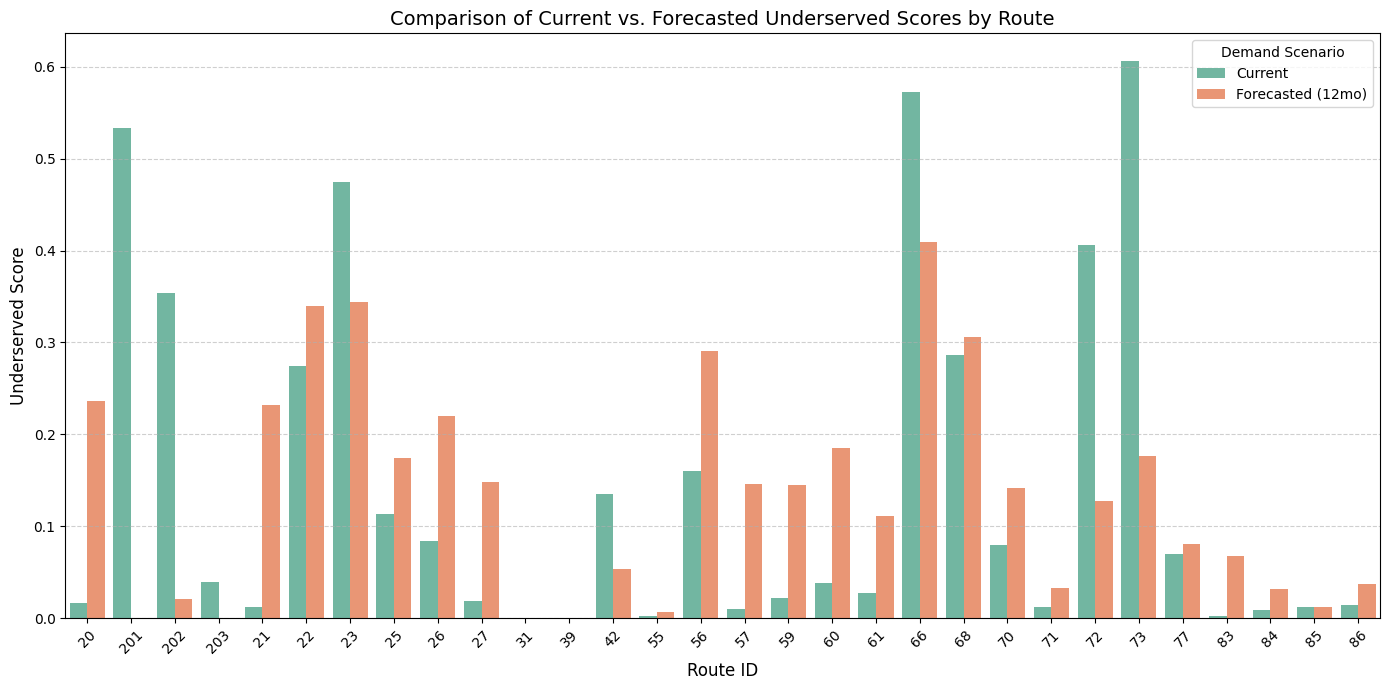

Routes predicted to be underserved in the future scenario: 201, 202, 23, 66


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for comparison
# We need to compare Underserved_Score from 'df_metrics' (current) with 'df_metrics_future' (forecasted)
# Merge them for side-by-side plotting
df_compare = pd.merge(
    df_metrics[['Route', 'Underserved_Score']].rename(columns={'Underserved_Score': 'Current_Score'}),
    df_metrics_future[['Route', 'Underserved_Score']].rename(columns={'Underserved_Score': 'Future_Score'}),
    on='Route',
    how='inner'
)

# 2. Reshape for Seaborn plotting (Melt)
df_plot = df_compare.melt(id_vars='Route', var_name='Scenario', value_name='Score')
df_plot['Scenario'] = df_plot['Scenario'].map({'Current_Score': 'Current', 'Future_Score': 'Forecasted (12mo)'})

# 3. Create the visualization
plt.figure(figsize=(14, 7))
sns.barplot(data=df_plot, x='Route', y='Score', hue='Scenario', palette='Set2')

plt.title('Comparison of Current vs. Forecasted Underserved Scores by Route', fontsize=14)
plt.xlabel('Route ID', fontsize=12)
plt.ylabel('Underserved Score', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Demand Scenario')
plt.tight_layout()
plt.show()

# 4. Summary of findings
newly_underserved = df_metrics_future[df_metrics_future['Is_Underserved_Future'] == 1]['Route'].tolist()
print(f"Routes predicted to be underserved in the future scenario: {', '.join(newly_underserved)}")